This assignment is based on the Tensor class. Your task is to train the MLP to perform classification on Fashion MNIST dataset. Your task is to perform hyperparameter search to look for the best hyperparameters for this specific task.

In this assignment, you should apply both Grid Search and Random Search to illustrate the differences in their results. To ensure a fair comparison, the total number of model evaluations should be equal for both Grid Search and Random Search.
Be sure to present your findings for both scenarios: using a simple train-validation split and employing cross-validation.
Additionally, you are encouraged to experiment with any other hyperparameter optimization techniques you are familiar with.

Try to find the best hyperparameters in space of:

(1) Batch Size

(2) Learning Rate

(3) Number of Epochs

(4) Activation Functions (here you need to modify MLP Class)

(5) Architectures (Different number of layers, different number of neurons per layer)

In [ ]:
from itertools import product
from typing import List

import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, StratifiedKFold

from Tensor import Tensor

In [2]:
class MLP:
    def __init__(self, n_in: int, n_out: int, hidden_dims: list, activation: str = "relu"):
        sizes = [n_in] + hidden_dims + [n_out]
        self.layers = []
        self.activation = activation

        for i in range(len(sizes)-1):
            layer = Tensor(shape=(sizes[i+1], sizes[i]), label=f'layer {i}')
            layer.data = np.random.uniform(low=-0.05, high=0.05, size=(sizes[i+1], sizes[i]))
            self.layers.append(layer)

    def apply_activation(self, x):
        if self.activation == "relu":
            return x.relu()
        elif self.activation == "leaky_relu":
            return x.leaky_relu()
        else:
            raise ValueError("Unknown activation")

    def __call__(self, x):
        for idx, layer in enumerate(self.layers):
            x = layer @ x
            if idx < len(self.layers) - 1:
                x = self.apply_activation(x)
        return x

    def parameters(self):
        return self.layers

In [ ]:
class MNIST_Net:
    def __init__(self, hidden_dims=[64], activation="relu"):
        self.mlp = MLP(
            n_in=784,
            n_out=10,
            hidden_dims=hidden_dims,
            activation=activation
        )

    def __call__(self, x):
        return self.mlp(x).softmax()

    def parameters(self):
        return self.mlp.parameters()


model = MNIST_Net()

In [4]:
def validate(model, X_set, Y_set):
    """
    Evaluate the accuracy of the model on a given dataset.

    This function performs a forward pass on each sample in the dataset,
    predicts the class, and compares it to the true class to calculate
    the overall accuracy.
    """
    correct_predictions = 0
    total_predictions = 0

    for i in range(X_set.shape[0]):
        x = X_set[i]
        y_true = Y_set[i]

        # Forward pass
        y_pred = model(x)

        # Get the predicted class (assuming y_pred is a Tensor with probabilities)
        predicted_class = np.argmax(y_pred.data)

        # Check if the prediction is correct
        if predicted_class == y_true:
            correct_predictions += 1

        total_predictions += 1

    # Calculate accuracy
    accuracy = correct_predictions / total_predictions
    return accuracy

In [5]:
# Load Fashion MNIST
fashion_mnist = fetch_openml('Fashion-MNIST', version=1)
images, labels = fashion_mnist.data, fashion_mnist.target

images = images.values.reshape(-1, 28, 28)
labels = labels.values
X_train, X_test, y_train, y_test = train_test_split(images, labels, train_size=60000, test_size=10000, stratify=labels, random_state=42)
print(X_train.shape, y_train.shape)

(60000, 28, 28) (60000,)


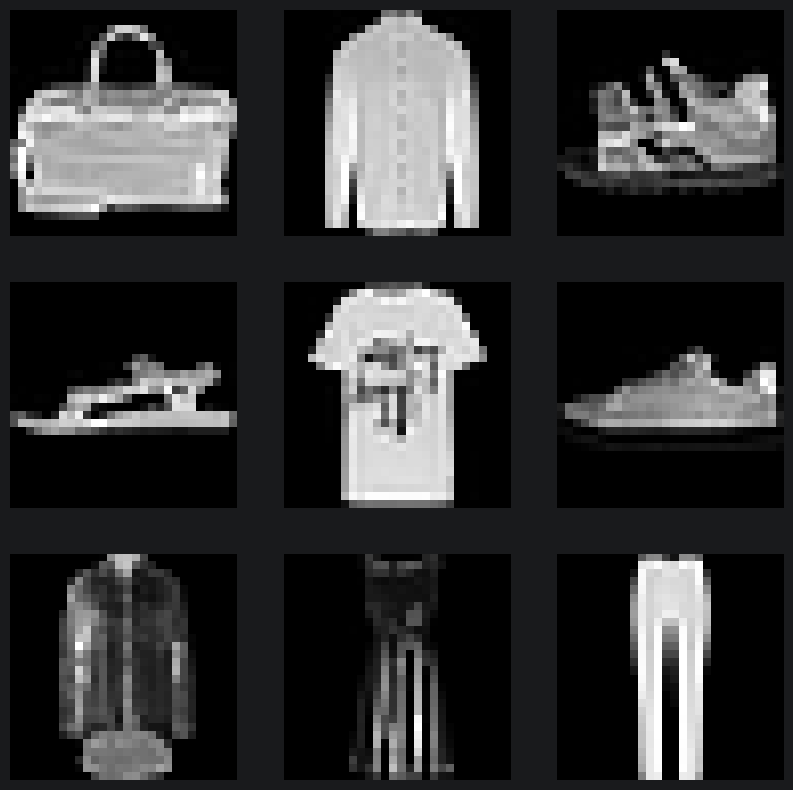

In [6]:
fig, axs = plt.subplots(3, 3, figsize=(10, 10))
for i in range(9):
    ax = axs[i // 3, i % 3]
    ax.imshow(X_train[i].reshape(28, 28), cmap='gray')
    ax.axis('off')

In [7]:
# Normalize the input data:
X_train = X_train.astype("float32").reshape(-1, 784) / 255.0
X_test = X_test.astype("float32").reshape(-1, 784) / 255.0

y_train = y_train.astype("int64")
y_test = y_test.astype("int64")

**TRAIN-VAL-TEST**

 In this section, we will search for hyperparameters by splitting the data into a training set (50,000 samples) and a validation set (10,000 samples). We will conduct the hyperparameter search using both Grid Search and Random Search methods.

In [8]:
X_train_full = X_train
y_train_full = y_train

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    train_size=50000,
    test_size=10000,
    stratify=y_train_full,
    random_state=42
)

In [ ]:
def train_model(model, X_data, y_data, batch_size, num_epochs, lr):
    """Train one model on the given data split."""
    for epoch in range(num_epochs):
        indices = np.arange(X_data.shape[0])
        np.random.shuffle(indices)

        X_shuffled = X_data[indices]
        y_shuffled = y_data[indices]

        for i in range(0, X_shuffled.shape[0], batch_size):
            X_batch = X_shuffled[i:i + batch_size]
            y_batch = y_shuffled[i:i + batch_size]

            X_tensors = [Tensor(data=x.flatten()) for x in X_batch]
            preds = [model(x) for x in X_tensors]

            mb_loss = sum([
                ypred.cross_entropy(ytrue)
                for ytrue, ypred in zip(y_batch, preds)
            ]) / batch_size

            for p in model.parameters():
                p.grad = np.zeros_like(p.grad)

            mb_loss.backward()

            for p in model.parameters():
                p.data -= lr * p.grad

    return model


In [ ]:
def train_and_evaluate(batch_size: int = 32,
                       num_epochs: int = 50,
                       lr: float = 0.001,
                       hidden_dims: List[int] = [64],
                       activation: str = "relu",
                       test_evaluation: bool = False):
    """Train on the fixed training split and evaluate on validation/test data."""
    model = MNIST_Net(
        hidden_dims=hidden_dims,
        activation=activation
    )

    trained_model = train_model(
        model=model,
        X_data=X_train,
        y_data=y_train,
        batch_size=batch_size,
        num_epochs=num_epochs,
        lr=lr
    )

    validation_accuracy = validate(trained_model, X_val, y_val)

    if test_evaluation:
        test_accuracy = validate(trained_model, X_test, y_test)
        return validation_accuracy, test_accuracy

    return validation_accuracy


In [ ]:
def make_combinations(search_space):
    return list(product(
        search_space["batch_size"],
        search_space["lr"],
        search_space["num_epochs"],
        search_space["activation"],
        search_space["hidden_dims"]
    ))


def make_config(batch_size, lr, num_epochs, activation, hidden_dims):
    return {
        "batch_size": batch_size,
        "lr": lr,
        "num_epochs": num_epochs,
        "activation": activation,
        "hidden_dims": hidden_dims
    }


def evaluate_config(config):
    val_acc = train_and_evaluate(
        batch_size=config["batch_size"],
        num_epochs=config["num_epochs"],
        lr=config["lr"],
        hidden_dims=config["hidden_dims"],
        activation=config["activation"]
    )

    result = config.copy()
    result["val_acc"] = val_acc
    return result


def run_grid_search(search_space):
    combinations = make_combinations(search_space)
    results = []

    for batch_size, lr, num_epochs, activation, hidden_dims in tqdm(combinations):
        config = make_config(batch_size, lr, num_epochs, activation, hidden_dims)
        results.append(evaluate_config(config))

    best_result = max(results, key=lambda x: x["val_acc"])
    return results, best_result


def run_random_search(search_space, n_evaluations, seed=42):
    all_combinations = make_combinations(search_space)

    if n_evaluations > len(all_combinations):
        raise ValueError("n_evaluations cannot be larger than the search space.")

    rng = np.random.default_rng(seed)
    random_indices = rng.choice(
        len(all_combinations),
        size=n_evaluations,
        replace=False
    )
    random_combinations = [all_combinations[i] for i in random_indices]

    results = []
    for batch_size, lr, num_epochs, activation, hidden_dims in tqdm(random_combinations):
        config = make_config(batch_size, lr, num_epochs, activation, hidden_dims)
        results.append(evaluate_config(config))

    best_result = max(results, key=lambda x: x["val_acc"])
    return results, best_result

In [ ]:
# Kurzer Check, ob die Aktivierungsfunktionen funktionieren.
for activation in ["relu", "leaky_relu"]:
    val_acc = train_and_evaluate(
        batch_size=64,
        num_epochs=1,
        lr=0.001,
        hidden_dims=[64],
        activation=activation
    )
    print(activation, val_acc)

In [ ]:
# Kurzer Check, ob es funktioniert.
val_acc = train_and_evaluate(
    batch_size=64,
    num_epochs=10,
    lr=0.001,
    hidden_dims=[128, 128, 64],
    activation="relu"
)
print(val_acc)

Grid Search


In [12]:
param_grid = {
    "batch_size": [64, 128],
    "lr": [0.005, 0.001, 0.01],
    "num_epochs": [3, 5, 10],
    "activation": ["relu", "leaky_relu"],
    "hidden_dims": [[64], [128], [128, 64]]
}

In [ ]:
grid_combinations = make_combinations(param_grid)
print("Total grid combinations:", len(grid_combinations))


In [ ]:
grid_results, best_grid_result = run_grid_search(param_grid)
best_grid_result

In [ ]:
# Optional debugging run with only 5 random grid combinations.
# rng = np.random.default_rng(42)
# debug_indices = rng.choice(len(grid_combinations), size=5, replace=False)
# debug_combinations = [grid_combinations[i] for i in debug_indices]


In [ ]:
# Optional debugging loop. Uncomment only if you do not want to run the full grid.
# grid_results = []
# for batch_size, lr, num_epochs, activation, hidden_dims in tqdm(debug_combinations):
#     config = make_config(batch_size, lr, num_epochs, activation, hidden_dims)
#     grid_results.append(evaluate_config(config))
# best_grid_result = max(grid_results, key=lambda x: x["val_acc"])
# best_grid_result


In [ ]:
best_grid_result

Random Search


In [ ]:
random_search_space = {
    "batch_size": [32, 64, 128, 256, 512],
    "lr": [0.0001, 0.0005, 0.001, 0.005, 0.01, 0.05],
    "num_epochs": [1, 3, 5, 10, 15, 20],
    "activation": ["relu", "leaky_relu"],
    "hidden_dims": [[32], [64], [128], [256], [64, 32], [128, 64], [128, 128], [256, 128]]
}


In [ ]:
random_evaluations = len(grid_combinations)
print("Random-search evaluations:", random_evaluations)


In [ ]:
random_results, best_random_result = run_random_search(
    random_search_space,
    n_evaluations=random_evaluations,
    seed=42
)

best_random_result

In [ ]:
best_train_val_result = max(best_grid_result, best_random_result, key=lambda x: x["val_acc"])
best_train_val_result

Cross-Validation


In [ ]:
def train_and_evaluate_cv(batch_size: int = 32,
                          num_epochs: int = 3,
                          lr: float = 0.001,
                          hidden_dims: List[int] = [64],
                          activation: str = "relu",
                          folds: int = 3):
    """Train and evaluate one hyperparameter config with stratified cross-validation."""
    validation_accuracies = []

    skf = StratifiedKFold(
        n_splits=folds,
        shuffle=True,
        random_state=42
    )

    for train_index, val_index in skf.split(X_train_full, y_train_full):
        X_fold_train = X_train_full[train_index]
        X_fold_val = X_train_full[val_index]
        y_fold_train = y_train_full[train_index]
        y_fold_val = y_train_full[val_index]

        model = MNIST_Net(
            hidden_dims=hidden_dims,
            activation=activation
        )

        model = train_model(
            model=model,
            X_data=X_fold_train,
            y_data=y_fold_train,
            batch_size=batch_size,
            num_epochs=num_epochs,
            lr=lr
        )

        validation_accuracy = validate(model, X_fold_val, y_fold_val)
        validation_accuracies.append(validation_accuracy)

    return np.mean(validation_accuracies)


def evaluate_config_cv(config, folds=3):
    mean_val_acc = train_and_evaluate_cv(
        batch_size=config["batch_size"],
        num_epochs=config["num_epochs"],
        lr=config["lr"],
        hidden_dims=config["hidden_dims"],
        activation=config["activation"],
        folds=folds
    )

    result = config.copy()
    result["mean_val_acc"] = mean_val_acc
    return result


def run_cv_grid_search(search_space, folds=3):
    combinations = make_combinations(search_space)
    results = []

    for batch_size, lr, num_epochs, activation, hidden_dims in tqdm(combinations):
        config = make_config(batch_size, lr, num_epochs, activation, hidden_dims)
        results.append(evaluate_config_cv(config, folds=folds))

    best_result = max(results, key=lambda x: x["mean_val_acc"])
    return results, best_result


def run_cv_random_search(search_space, n_evaluations, folds=3, seed=42):
    all_combinations = make_combinations(search_space)

    if n_evaluations > len(all_combinations):
        raise ValueError("n_evaluations cannot be larger than the search space.")

    rng = np.random.default_rng(seed)
    random_indices = rng.choice(
        len(all_combinations),
        size=n_evaluations,
        replace=False
    )
    random_combinations = [all_combinations[i] for i in random_indices]

    results = []
    for batch_size, lr, num_epochs, activation, hidden_dims in tqdm(random_combinations):
        config = make_config(batch_size, lr, num_epochs, activation, hidden_dims)
        results.append(evaluate_config_cv(config, folds=folds))

    best_result = max(results, key=lambda x: x["mean_val_acc"])
    return results, best_result


In [ ]:
cv_acc = train_and_evaluate_cv(
    batch_size=128,
    num_epochs=1,
    lr=0.001,
    hidden_dims=[64],
    activation="relu",
    folds=3
)

print(cv_acc)

In [ ]:
cv_param_grid = {
    "batch_size": [128],
    "lr": [0.001, 0.01],
    "num_epochs": [1, 3],
    "activation": ["relu", "leaky_relu"],
    "hidden_dims": [[64]]
}

In [ ]:
cv_grid_combinations = make_combinations(cv_param_grid)
print("Total CV grid combinations:", len(cv_grid_combinations))

cv_grid_results, best_cv_grid_result = run_cv_grid_search(
    cv_param_grid,
    folds=3
)

best_cv_grid_result


Cross-Validation Random Search


In [ ]:
cv_random_evaluations = len(cv_grid_combinations)
print("CV random-search evaluations:", cv_random_evaluations)

cv_random_results, best_cv_random_result = run_cv_random_search(
    random_search_space,
    n_evaluations=cv_random_evaluations,
    folds=3,
    seed=42
)

best_cv_random_result

Vergleich


In [ ]:
best_cv_result = max(
    best_cv_grid_result,
    best_cv_random_result,
    key=lambda x: x["mean_val_acc"]
)

print("Best train-validation result:")
print(best_train_val_result)

print("Best cross-validation result:")
print(best_cv_result)